<a href="https://colab.research.google.com/github/TimofeyProtasov/diploma/blob/main/days/forth_graphics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
def load_all_results(save_dir: str, path="results_train_*.csv") -> pd.DataFrame:
    all_files = Path(save_dir).glob(path)
    df_list = []
    for file in all_files:
        df = pd.read_csv(file)
        df_list.append(df)
    if df_list:
        return pd.concat(df_list, ignore_index=True)
    else:
        return pd.DataFrame()


# loha gold 1.5


In [3]:
df_all = load_all_results("/content/drive/MyDrive/rag_experiments_1_5_second", "results_train_*_loha_config_1_5b.csv")
print(df_all)

   train_size  trainable_params_m  before_train_peak_memory_gb  \
0         100           36.929536                         3.74   
1         300           36.929536                         3.76   
2         500           36.929536                         3.76   
3         700           36.929536                         3.76   

   train_time_min  train_peak_memory_gb    f1  evaluate_f1_time_min  \
0            2.31                  8.02  0.00                  5.26   
1            6.84                  8.02  0.28                  6.01   
2           11.35                  8.02  0.71                  7.01   
3           16.03                  8.02  0.70                  7.73   

   evaluate_f1_peak_memory_gb  perplexity  evaluate_perplexity_time_min  ...  \
0                        4.48        2.11                          0.16  ...   
1                        4.41        1.61                          0.16  ...   
2                        4.38        1.41                          0.16  

In [5]:

# 1. Вручную соберём длинный формат
records = []
for _, row in df_all.iterrows():
    train_size = row['train_size']
    for ep in [4, 6, 8, 10]:
        records.append({
            'train_size': train_size,
            'epoch': ep,
            'f1': row[f'f1_epoch{ep}'],
            'perplexity': row[f'perplexity_epoch{ep}'],
            'f1_time': row[f'f1_time_epoch{ep}'],
            'f1_memory': row[f'f1_memory_epoch{ep}'],
            'perplexity_time': row[f'perplexity_time_epoch{ep}'],
            'perplexity_memory': row[f'perplexity_memory_epoch{ep}'],
            'train_time': row['train_time_min'],
            'train_memory': row['train_peak_memory_gb']
        })

df_long = pd.DataFrame(records)


In [6]:
df_long

,train_size,epoch,f1,perplexity,f1_time,f1_memory,perplexity_time,perplexity_memory,train_time,train_memory
0,100.0,4,0.00,2.31,2.81,4.48,0.16,5.69,2.31,8.02
1,100.0,6,0.00,2.22,3.52,4.48,0.16,5.69,2.31,8.02
2,100.0,8,0.00,2.15,4.46,4.48,0.16,5.69,2.31,8.02
3,100.0,10,0.00,2.11,5.26,4.48,0.16,5.69,2.31,8.02
4,300.0,4,0.04,1.72,8.70,4.41,0.16,5.44,6.84,8.02
5,300.0,6,0.19,1.66,6.11,4.41,0.16,5.44,6.84,8.02
6,300.0,8,0.23,1.63,6.50,4.41,0.16,5.44,6.84,8.02
7,300.0,10,0.28,1.61,6.01,4.41,0.16,5.44,6.84,8.02
8,500.0,4,0.59,1.46,7.17,4.38,0.16,5.63,11.35,8.02
9,500.0,6,0.73,1.43,7.27,4.38,0.16,5.63,11.35,8.02


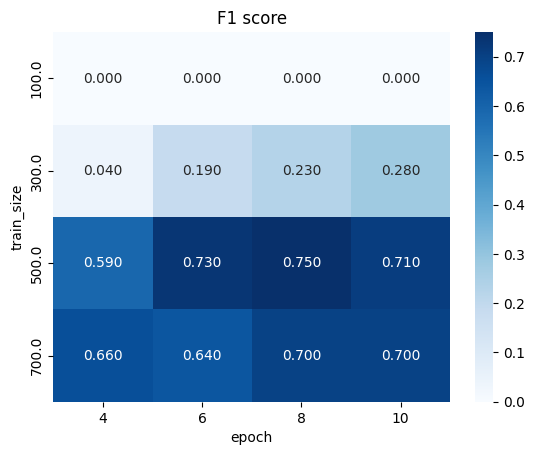

In [7]:

# 2. Heatmap (пример для f1)
pivot_f1 = df_long.pivot(index='train_size', columns='epoch', values='f1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Blues')
plt.title('F1 score')
plt.show()


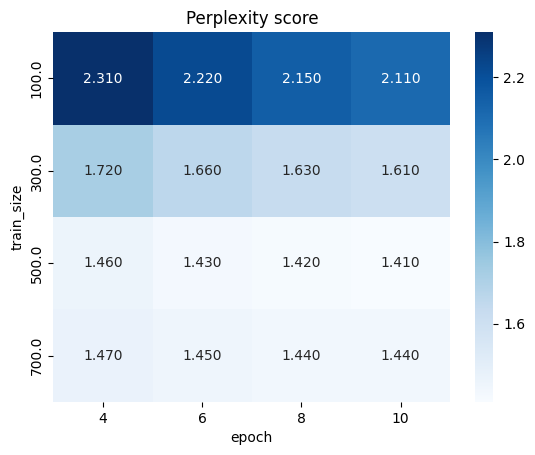

In [8]:

# 2. Heatmap (пример для Perplexity)
pivot_per = df_long.pivot(index='train_size', columns='epoch', values='perplexity')
sns.heatmap(pivot_per, annot=True, fmt='.3f', cmap='Blues')
plt.title('Perplexity score')
plt.show()


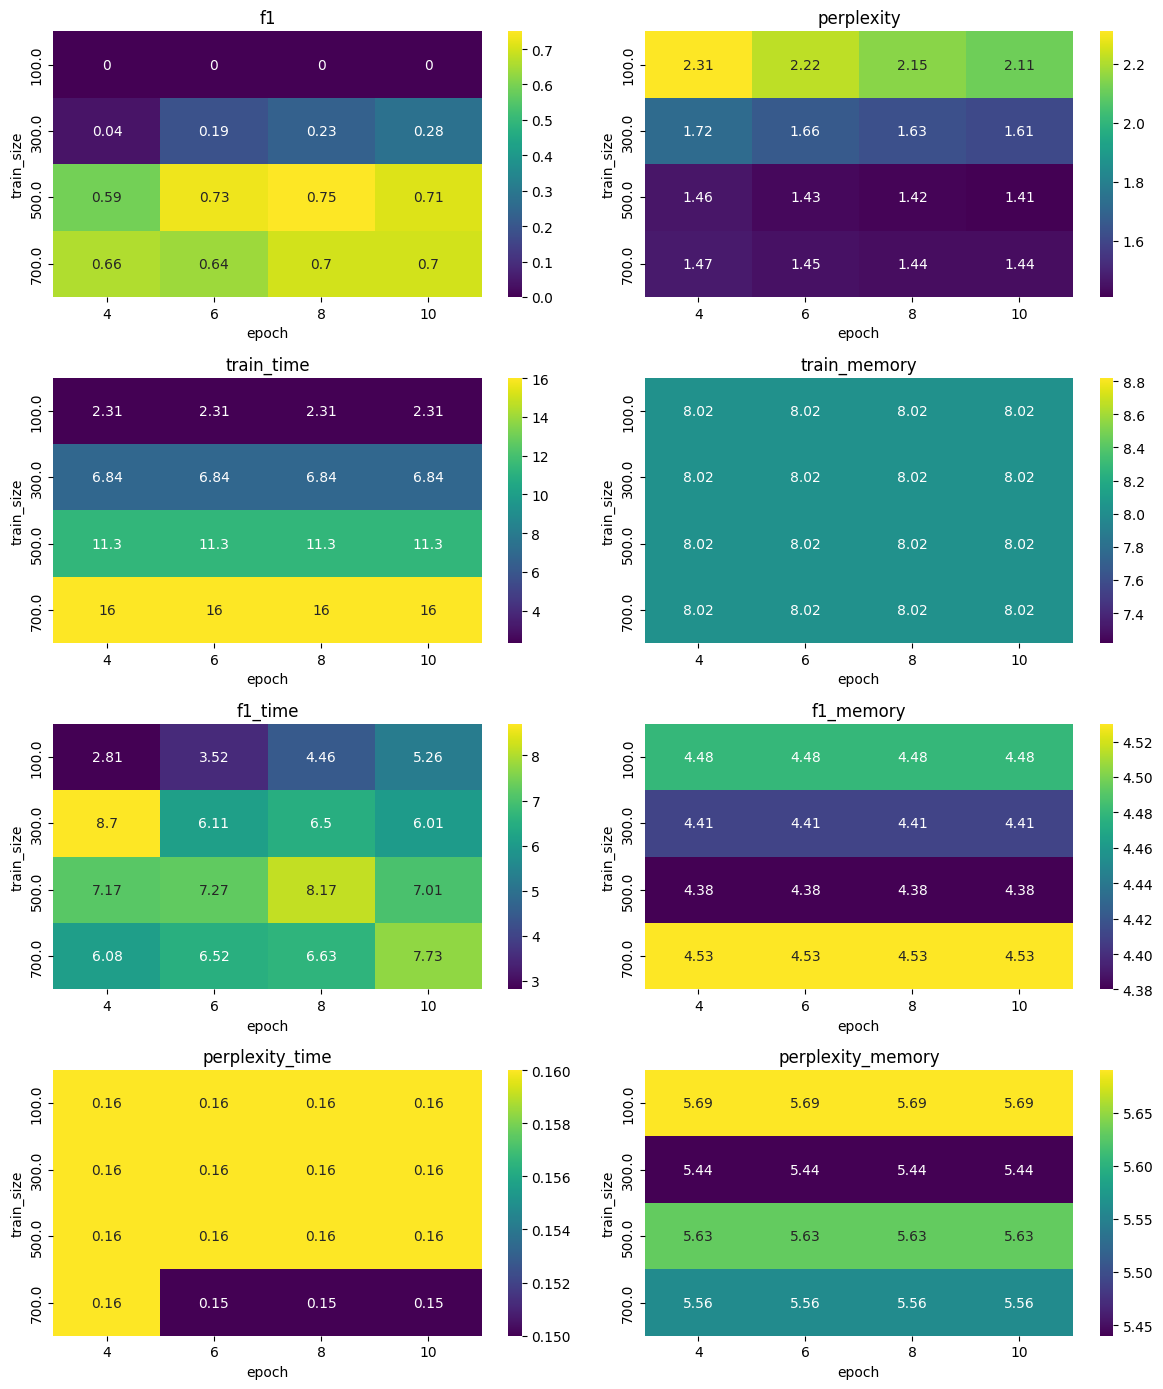

In [9]:

# 3. Все метрики в одном цикле
metrics = ['f1', 'perplexity', 'train_time', 'train_memory',
           'f1_time', 'f1_memory', 'perplexity_time', 'perplexity_memory']

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()
for ax, metric in zip(axes, metrics):
    pivot = df_long.pivot(index='train_size', columns='epoch', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3g', cmap='viridis', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('epoch')
    ax.set_ylabel('train_size')
plt.tight_layout()
plt.show()

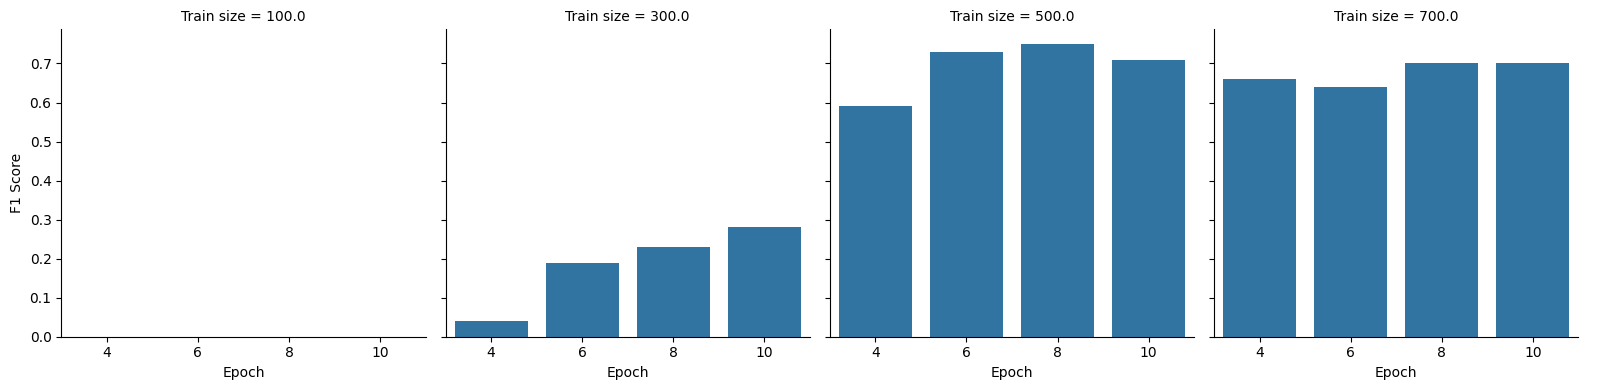

In [10]:
g = sns.catplot(data=df_long, x='epoch', y='f1', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "F1 Score")
g.set_titles("Train size = {col_name}")
plt.show()

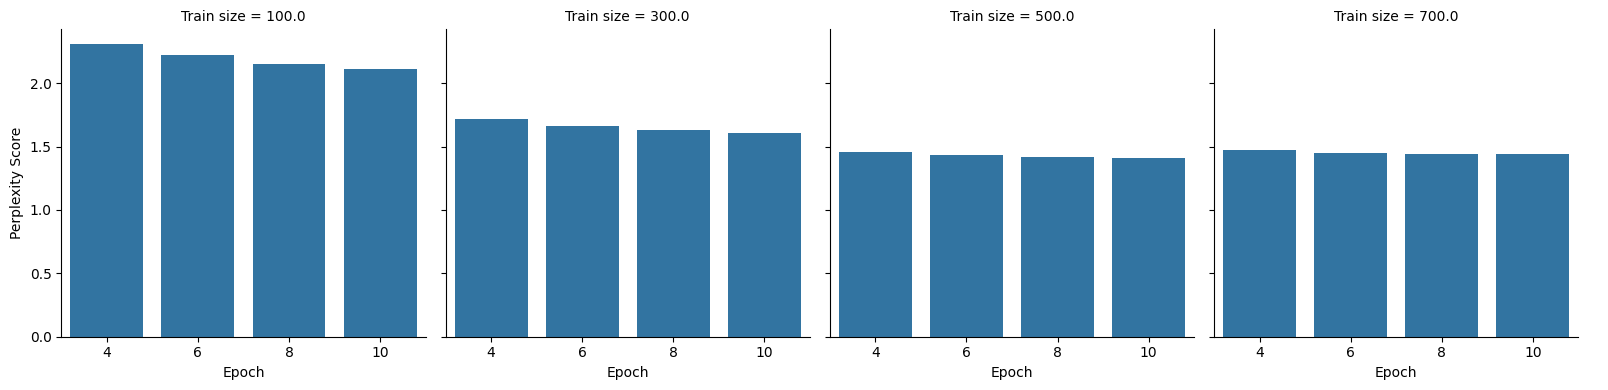

In [11]:
g = sns.catplot(data=df_long, x='epoch', y='perplexity', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "Perplexity Score")
g.set_titles("Train size = {col_name}")
plt.show()

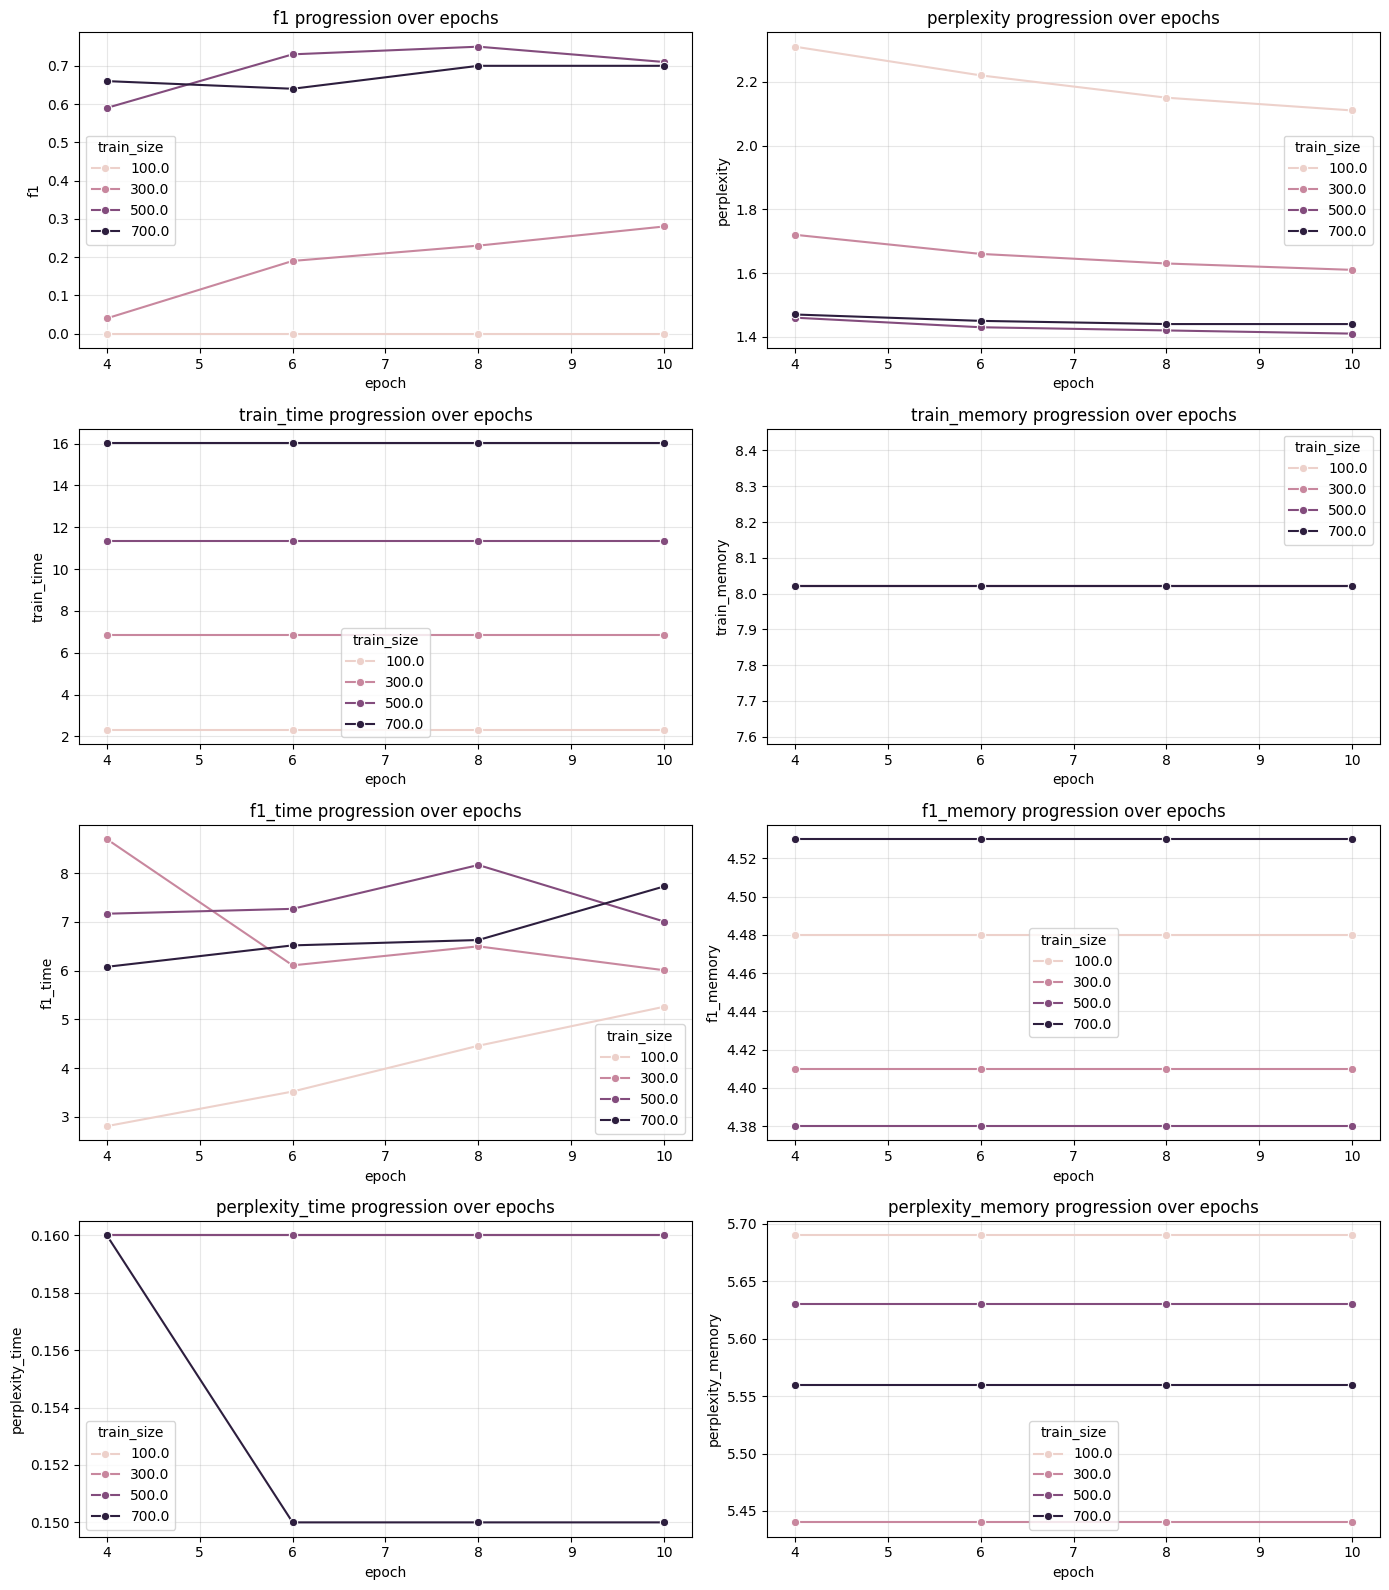

In [12]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.lineplot(data=df_long, x='epoch', y=metric, hue='train_size',
                 marker='o', ax=ax)
    ax.set_title(f'{metric} progression over epochs')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# loha 0.8 1.5


In [22]:
df_all = load_all_results("/content/drive/MyDrive/rag_experiments_1_5_second", "results_train_*_loha_config_1_5b_oracle.csv")
print(df_all)

   train_size  trainable_params_m  before_train_peak_memory_gb  \
0         100           36.929536                         3.76   
1         300           36.929536                         3.76   
2         500           36.929536                         3.76   
3         700           36.929536                         3.76   

   train_time_min  train_peak_memory_gb    f1  evaluate_f1_time_min  \
0            2.31                  8.02  0.00                  3.87   
1            6.84                  8.02  0.20                  7.02   
2           11.40                  8.02  0.57                  6.66   
3           15.99                  8.02  0.60                  9.64   

   evaluate_f1_peak_memory_gb  perplexity  evaluate_perplexity_time_min  ...  \
0                        4.48        2.31                          0.16  ...   
1                        4.30        1.85                          0.16  ...   
2                        4.38        1.63                          0.15  

In [23]:

# 1. Вручную соберём длинный формат
records = []
for _, row in df_all.iterrows():
    train_size = row['train_size']
    for ep in [4, 6, 8, 10]:
        records.append({
            'train_size': train_size,
            'epoch': ep,
            'f1': row[f'f1_epoch{ep}'],
            'perplexity': row[f'perplexity_epoch{ep}'],
            'f1_time': row[f'f1_time_epoch{ep}'],
            'f1_memory': row[f'f1_memory_epoch{ep}'],
            'perplexity_time': row[f'perplexity_time_epoch{ep}'],
            'perplexity_memory': row[f'perplexity_memory_epoch{ep}'],
            'train_time': row['train_time_min'],
            'train_memory': row['train_peak_memory_gb']
        })

df_long = pd.DataFrame(records)


In [24]:
df_long

,train_size,epoch,f1,perplexity,f1_time,f1_memory,perplexity_time,perplexity_memory,train_time,train_memory
0,100.0,4,0.00,2.52,3.09,4.48,0.16,5.67,2.31,8.02
1,100.0,6,0.00,2.43,3.27,4.48,0.16,5.67,2.31,8.02
2,100.0,8,0.00,2.36,4.10,4.48,0.16,5.67,2.31,8.02
3,100.0,10,0.00,2.31,3.87,4.48,0.16,5.67,2.31,8.02
4,300.0,4,0.02,1.97,6.13,4.30,0.16,5.52,6.84,8.02
5,300.0,6,0.08,1.91,6.33,4.30,0.16,5.52,6.84,8.02
6,300.0,8,0.15,1.87,6.47,4.30,0.16,5.52,6.84,8.02
7,300.0,10,0.20,1.85,7.02,4.30,0.16,5.52,6.84,8.02
8,500.0,4,0.38,1.69,6.06,4.38,0.15,5.34,11.40,8.02
9,500.0,6,0.53,1.65,6.73,4.38,0.15,5.34,11.40,8.02


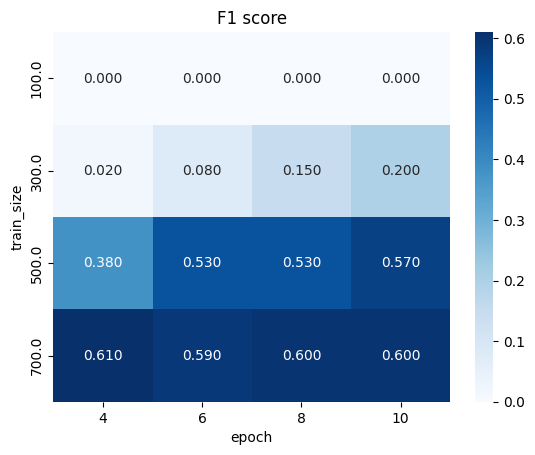

In [25]:

# 2. Heatmap (пример для f1)
pivot_f1 = df_long.pivot(index='train_size', columns='epoch', values='f1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Blues')
plt.title('F1 score')
plt.show()


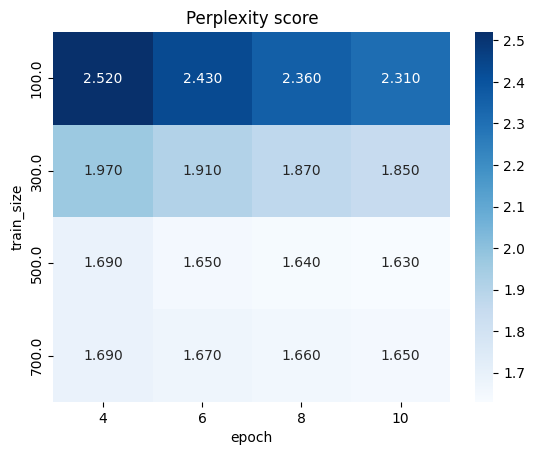

In [26]:

# 2. Heatmap (пример для Perplexity)
pivot_per = df_long.pivot(index='train_size', columns='epoch', values='perplexity')
sns.heatmap(pivot_per, annot=True, fmt='.3f', cmap='Blues')
plt.title('Perplexity score')
plt.show()


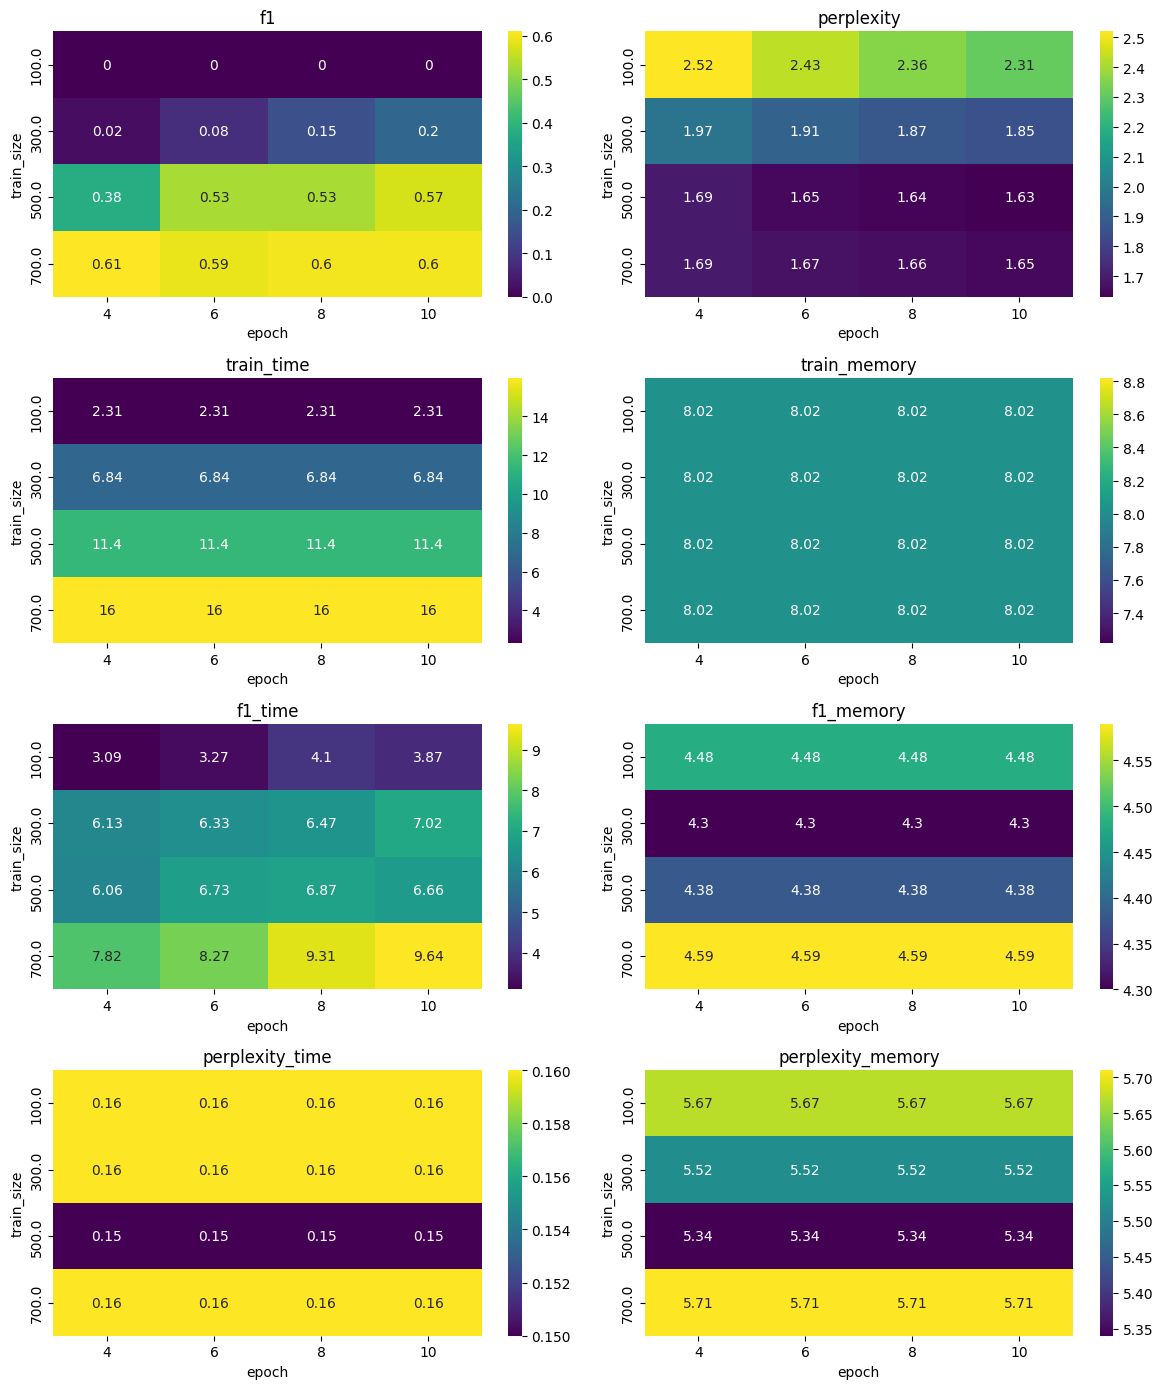

In [27]:

# 3. Все метрики в одном цикле
metrics = ['f1', 'perplexity', 'train_time', 'train_memory',
           'f1_time', 'f1_memory', 'perplexity_time', 'perplexity_memory']

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()
for ax, metric in zip(axes, metrics):
    pivot = df_long.pivot(index='train_size', columns='epoch', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3g', cmap='viridis', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('epoch')
    ax.set_ylabel('train_size')
plt.tight_layout()
plt.show()

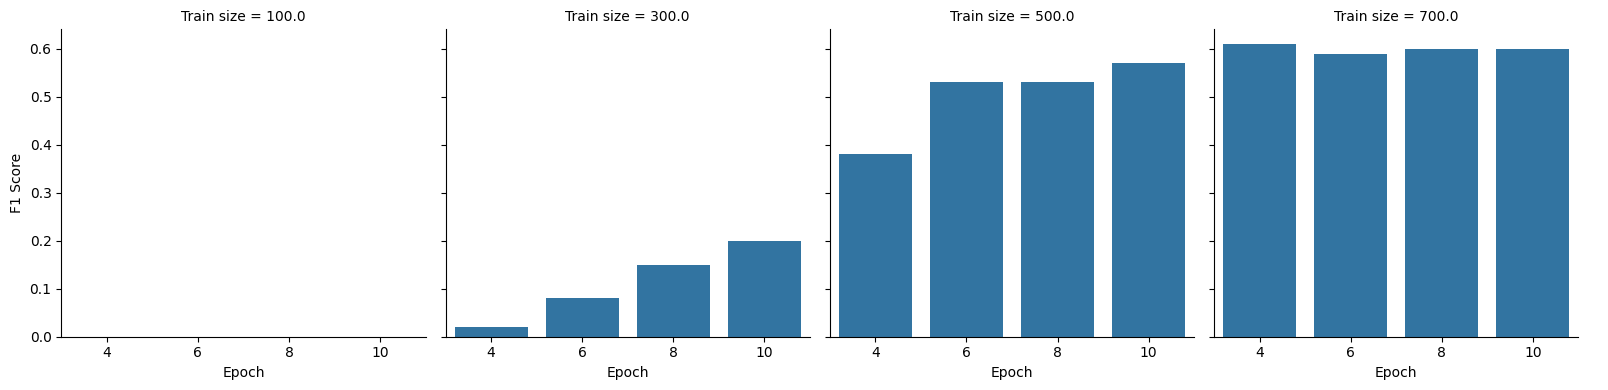

In [28]:
g = sns.catplot(data=df_long, x='epoch', y='f1', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "F1 Score")
g.set_titles("Train size = {col_name}")
plt.show()

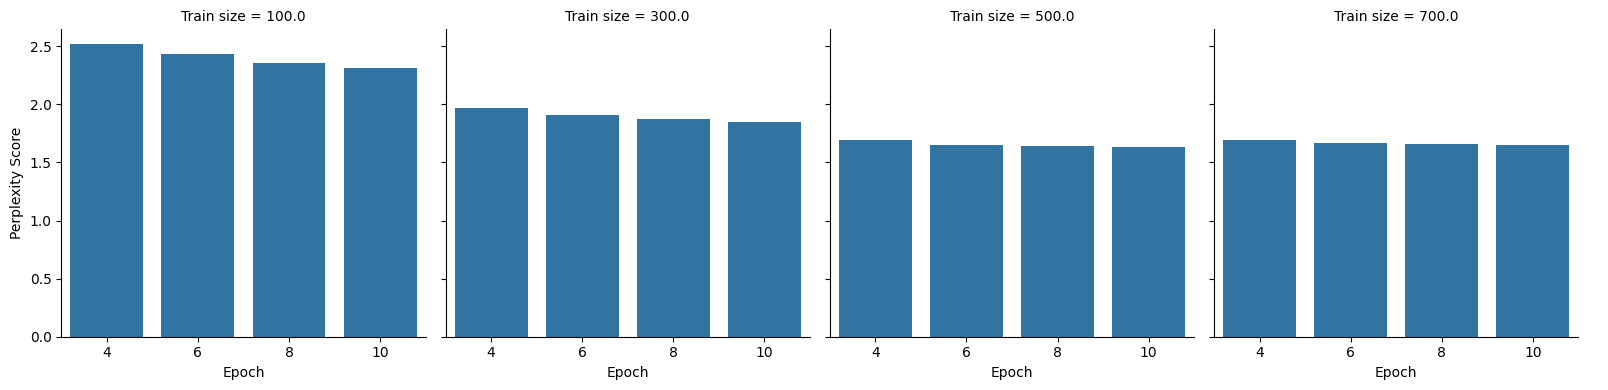

In [29]:
g = sns.catplot(data=df_long, x='epoch', y='perplexity', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "Perplexity Score")
g.set_titles("Train size = {col_name}")
plt.show()

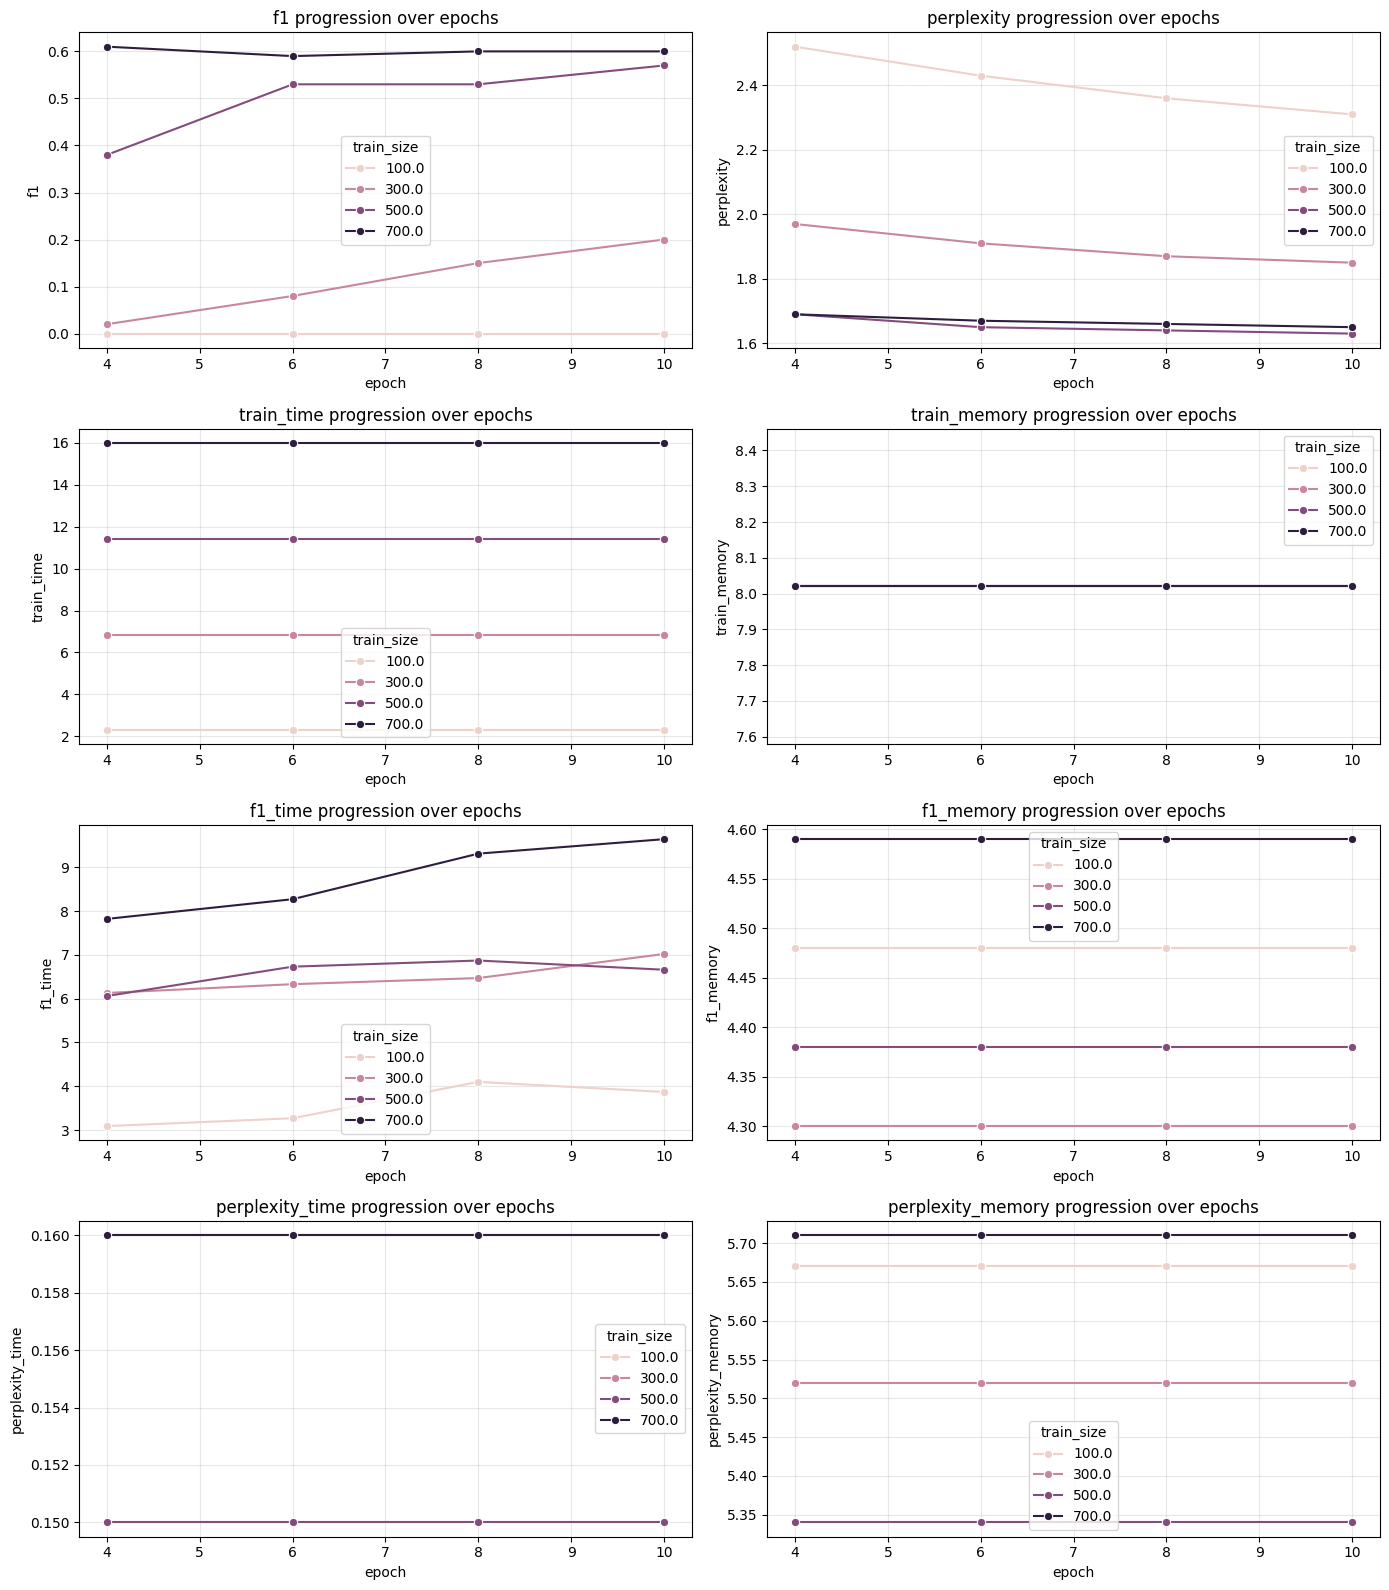

In [30]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.lineplot(data=df_long, x='epoch', y=metric, hue='train_size',
                 marker='o', ax=ax)
    ax.set_title(f'{metric} progression over epochs')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# lora 0.8 1.5


In [13]:
df_all = load_all_results("/content/drive/MyDrive/rag_experiments_1_5_second", "results_train_*_lora_config_1_5b_oracle.csv")
print(df_all)

   train_size  trainable_params_m  before_train_peak_memory_gb  \
0         100           18.464768                         3.76   
1         300           18.464768                         3.76   
2         500           18.464768                         3.76   
3         700           18.464768                         3.76   

   train_time_min  train_peak_memory_gb    f1  evaluate_f1_time_min  \
0            1.55                  7.74  0.62                  3.33   
1            4.59                  7.74  0.72                  2.80   
2            7.68                  7.74  0.67                  2.83   
3           10.81                  7.74  0.74                  2.96   

   evaluate_f1_peak_memory_gb  perplexity  evaluate_perplexity_time_min  ...  \
0                        4.33        1.56                          0.10  ...   
1                        4.13        1.69                          0.09  ...   
2                        4.21        1.60                          0.09  

In [14]:

# 1. Вручную соберём длинный формат
records = []
for _, row in df_all.iterrows():
    train_size = row['train_size']
    for ep in [4, 6, 8, 10]:
        records.append({
            'train_size': train_size,
            'epoch': ep,
            'f1': row[f'f1_epoch{ep}'],
            'perplexity': row[f'perplexity_epoch{ep}'],
            'f1_time': row[f'f1_time_epoch{ep}'],
            'f1_memory': row[f'f1_memory_epoch{ep}'],
            'perplexity_time': row[f'perplexity_time_epoch{ep}'],
            'perplexity_memory': row[f'perplexity_memory_epoch{ep}'],
            'train_time': row['train_time_min'],
            'train_memory': row['train_peak_memory_gb']
        })

df_long = pd.DataFrame(records)


In [15]:
df_long

,train_size,epoch,f1,perplexity,f1_time,f1_memory,perplexity_time,perplexity_memory,train_time,train_memory
0,100.0,4,0.66,1.56,2.90,4.33,0.10,5.43,1.55,7.74
1,100.0,6,0.59,1.56,2.96,4.33,0.10,5.43,1.55,7.74
2,100.0,8,0.61,1.56,2.87,4.33,0.10,5.43,1.55,7.74
3,100.0,10,0.62,1.56,3.33,4.33,0.10,5.43,1.55,7.74
4,300.0,4,0.71,1.64,2.97,4.13,0.09,5.28,4.59,7.74
5,300.0,6,0.69,1.65,3.15,4.13,0.10,5.28,4.59,7.74
6,300.0,8,0.71,1.67,2.91,4.13,0.09,5.28,4.59,7.74
7,300.0,10,0.72,1.69,2.80,4.13,0.09,5.28,4.59,7.74
8,500.0,4,0.76,1.53,2.59,4.21,0.09,5.10,7.68,7.74
9,500.0,6,0.77,1.55,2.85,4.21,0.09,5.10,7.68,7.74


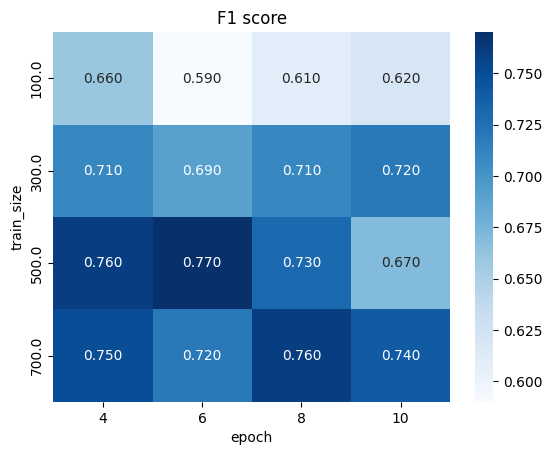

In [16]:

# 2. Heatmap (пример для f1)
pivot_f1 = df_long.pivot(index='train_size', columns='epoch', values='f1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Blues')
plt.title('F1 score')
plt.show()


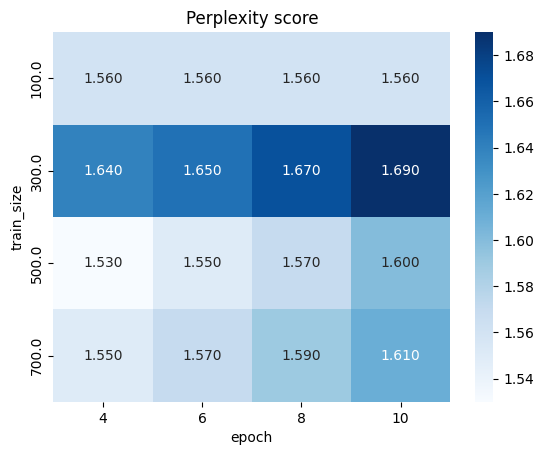

In [17]:

# 2. Heatmap (пример для Perplexity)
pivot_per = df_long.pivot(index='train_size', columns='epoch', values='perplexity')
sns.heatmap(pivot_per, annot=True, fmt='.3f', cmap='Blues')
plt.title('Perplexity score')
plt.show()


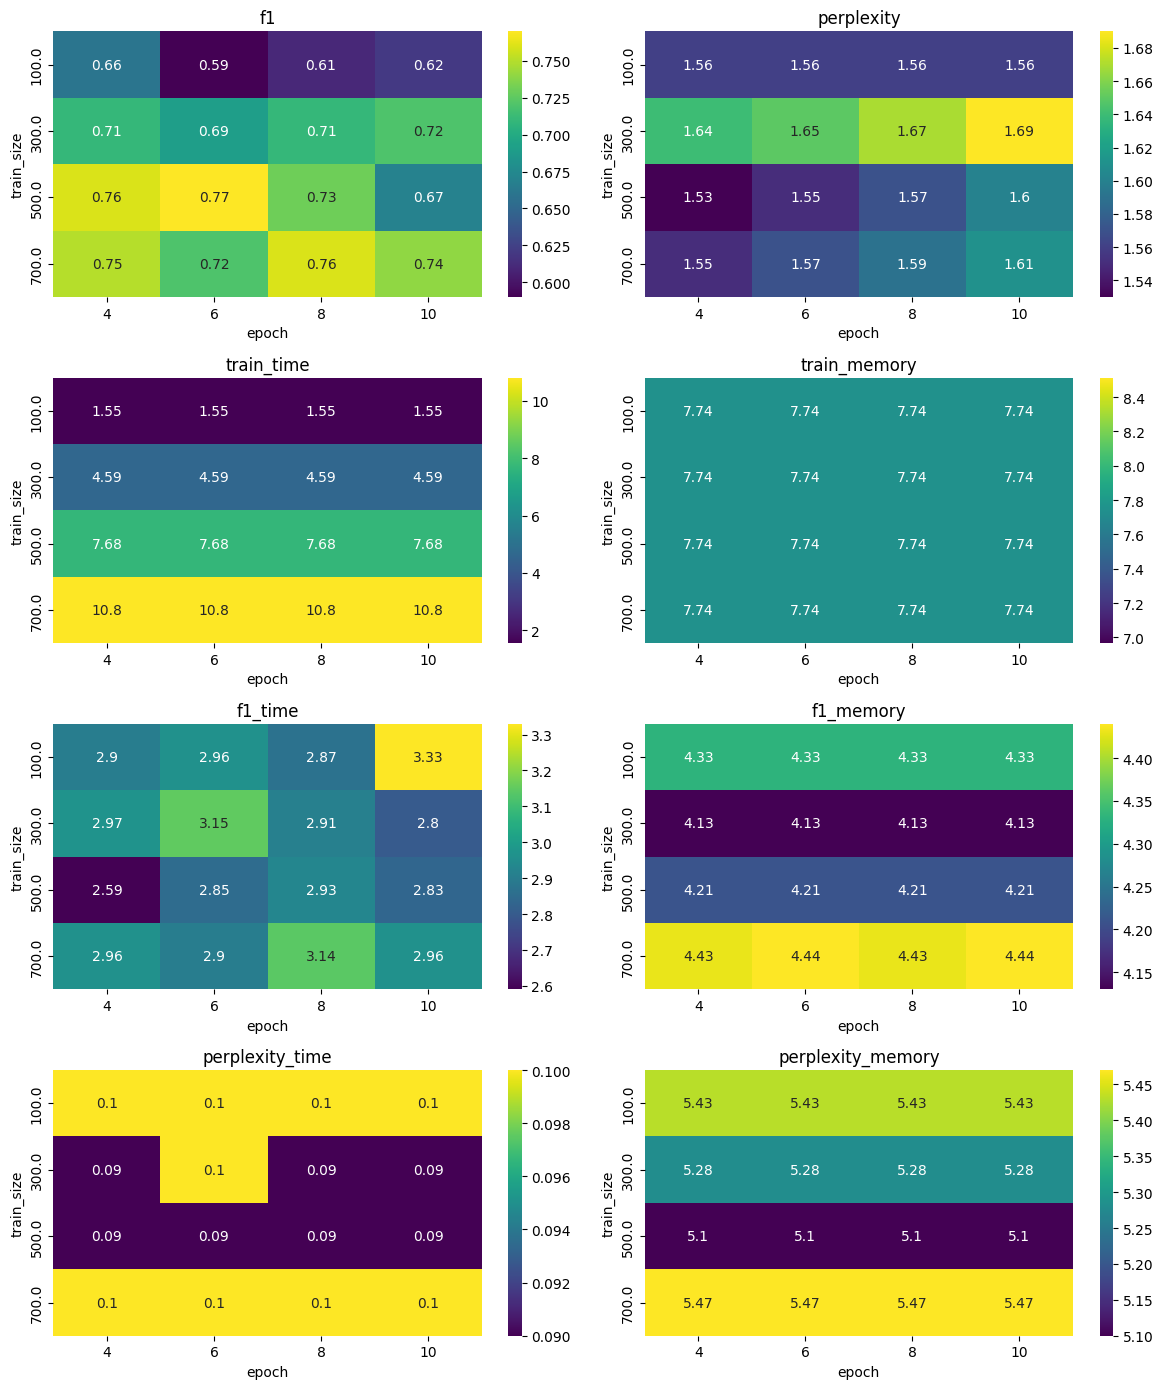

In [18]:

# 3. Все метрики в одном цикле
metrics = ['f1', 'perplexity', 'train_time', 'train_memory',
           'f1_time', 'f1_memory', 'perplexity_time', 'perplexity_memory']

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()
for ax, metric in zip(axes, metrics):
    pivot = df_long.pivot(index='train_size', columns='epoch', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3g', cmap='viridis', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('epoch')
    ax.set_ylabel('train_size')
plt.tight_layout()
plt.show()

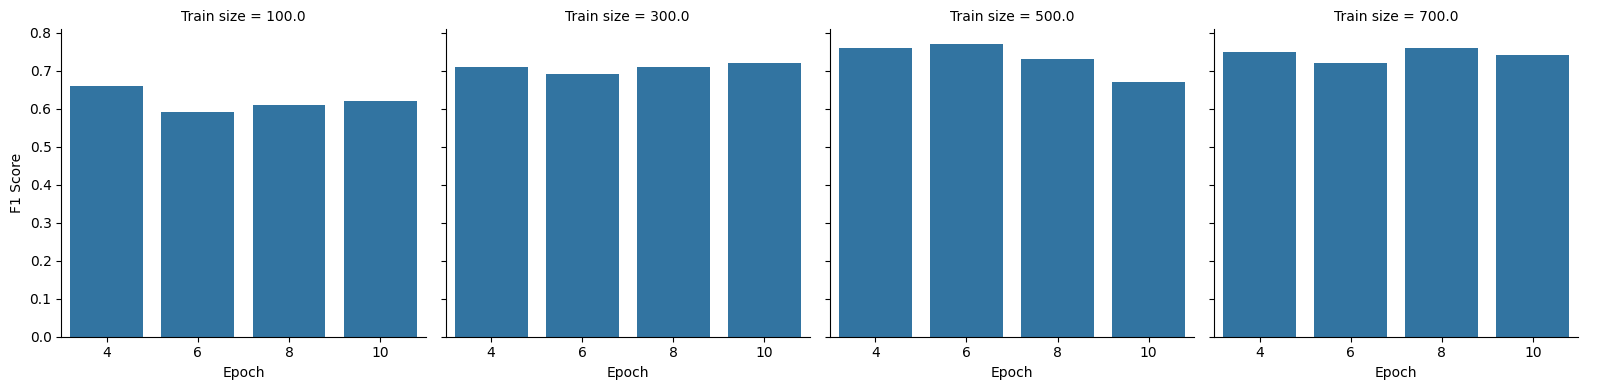

In [19]:
g = sns.catplot(data=df_long, x='epoch', y='f1', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "F1 Score")
g.set_titles("Train size = {col_name}")
plt.show()

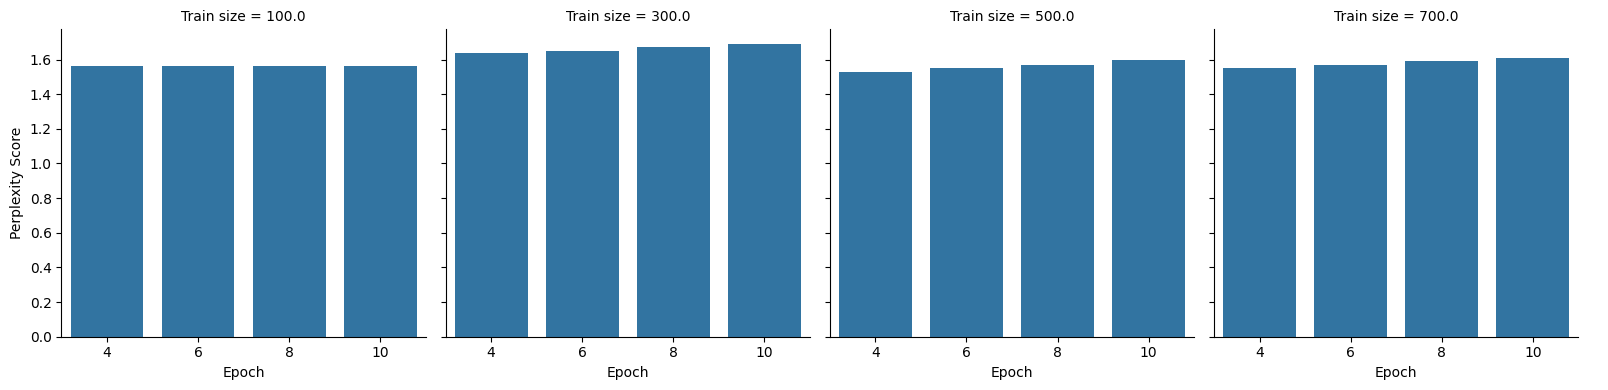

In [20]:
g = sns.catplot(data=df_long, x='epoch', y='perplexity', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "Perplexity Score")
g.set_titles("Train size = {col_name}")
plt.show()

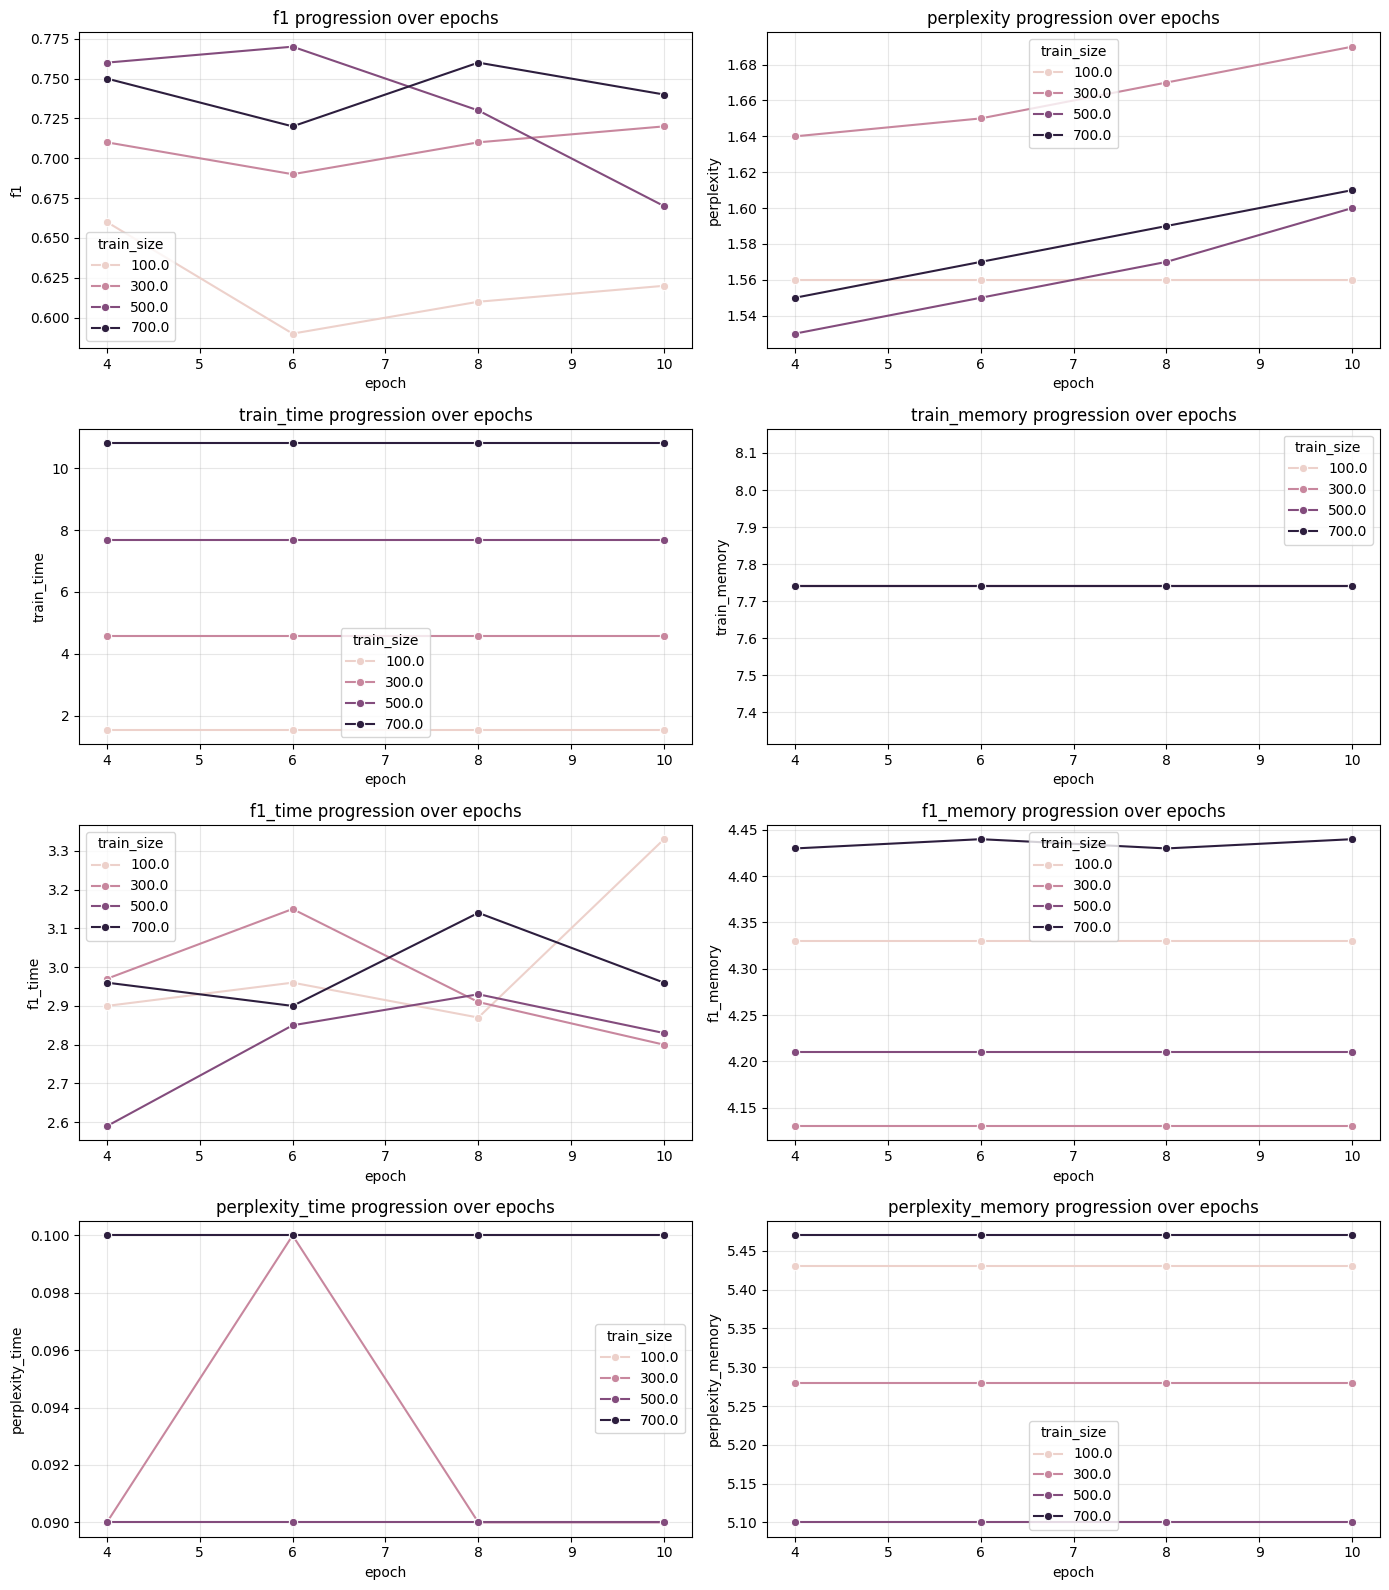

In [21]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.lineplot(data=df_long, x='epoch', y=metric, hue='train_size',
                 marker='o', ax=ax)
    ax.set_title(f'{metric} progression over epochs')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ia3 gold 1.5


In [31]:
df_all = load_all_results("/content/drive/MyDrive/rag_experiments_1_5_second", "results_train_*_ia3_config_1_5b.csv")
print(df_all)

   train_size  trainable_params_m  before_train_peak_memory_gb  \
0         100            0.265216                         3.76   
1         300            0.265216                         3.76   
2         500            0.265216                         3.76   
3         700            0.265216                         3.76   

   train_time_min  train_peak_memory_gb   f1  evaluate_f1_time_min  \
0            1.20                  7.47  0.0                  0.63   
1            3.55                  7.47  0.0                  1.37   
2            5.89                  7.47  0.0                  1.56   
3            8.36                  7.47  0.0                  1.59   

   evaluate_f1_peak_memory_gb  perplexity  evaluate_perplexity_time_min  ...  \
0                        4.07        2.50                          0.08  ...   
1                        4.00        2.28                          0.08  ...   
2                        3.97        1.88                          0.07  ...  

In [32]:

# 1. Вручную соберём длинный формат
records = []
for _, row in df_all.iterrows():
    train_size = row['train_size']
    for ep in [4, 6, 8, 10]:
        records.append({
            'train_size': train_size,
            'epoch': ep,
            'f1': row[f'f1_epoch{ep}'],
            'perplexity': row[f'perplexity_epoch{ep}'],
            'f1_time': row[f'f1_time_epoch{ep}'],
            'f1_memory': row[f'f1_memory_epoch{ep}'],
            'perplexity_time': row[f'perplexity_time_epoch{ep}'],
            'perplexity_memory': row[f'perplexity_memory_epoch{ep}'],
            'train_time': row['train_time_min'],
            'train_memory': row['train_peak_memory_gb']
        })

df_long = pd.DataFrame(records)


In [33]:
df_long

,train_size,epoch,f1,perplexity,f1_time,f1_memory,perplexity_time,perplexity_memory,train_time,train_memory
0,100.0,4,0.0,2.63,0.66,4.07,0.08,5.21,1.20,7.47
1,100.0,6,0.0,2.57,0.63,4.07,0.08,5.21,1.20,7.47
2,100.0,8,0.0,2.53,0.63,4.07,0.08,5.21,1.20,7.47
3,100.0,10,0.0,2.50,0.63,4.07,0.08,5.21,1.20,7.47
4,300.0,4,0.0,2.40,1.18,4.00,0.08,4.96,3.55,7.47
5,300.0,6,0.0,2.35,1.16,4.00,0.08,4.96,3.55,7.47
6,300.0,8,0.0,2.31,1.31,4.00,0.08,4.96,3.55,7.47
7,300.0,10,0.0,2.28,1.37,4.00,0.08,4.96,3.55,7.47
8,500.0,4,0.0,1.98,1.49,3.97,0.07,5.15,5.89,7.47
9,500.0,6,0.0,1.93,1.58,3.97,0.07,5.15,5.89,7.47


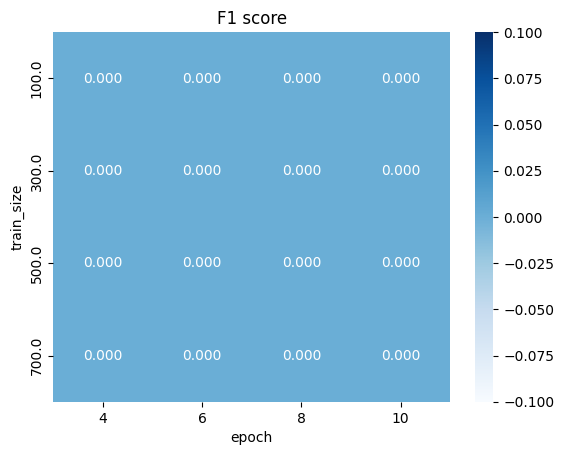

In [34]:

# 2. Heatmap (пример для f1)
pivot_f1 = df_long.pivot(index='train_size', columns='epoch', values='f1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Blues')
plt.title('F1 score')
plt.show()


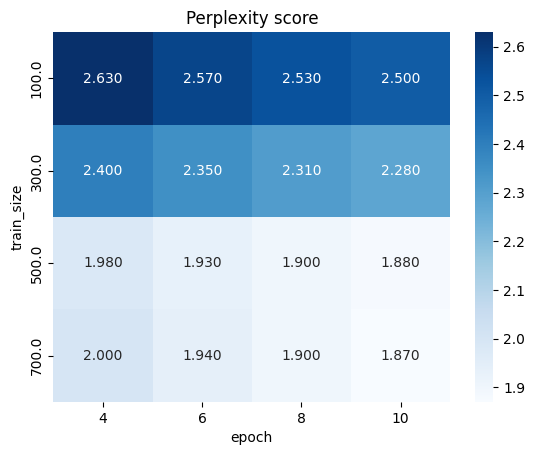

In [35]:

# 2. Heatmap (пример для Perplexity)
pivot_per = df_long.pivot(index='train_size', columns='epoch', values='perplexity')
sns.heatmap(pivot_per, annot=True, fmt='.3f', cmap='Blues')
plt.title('Perplexity score')
plt.show()


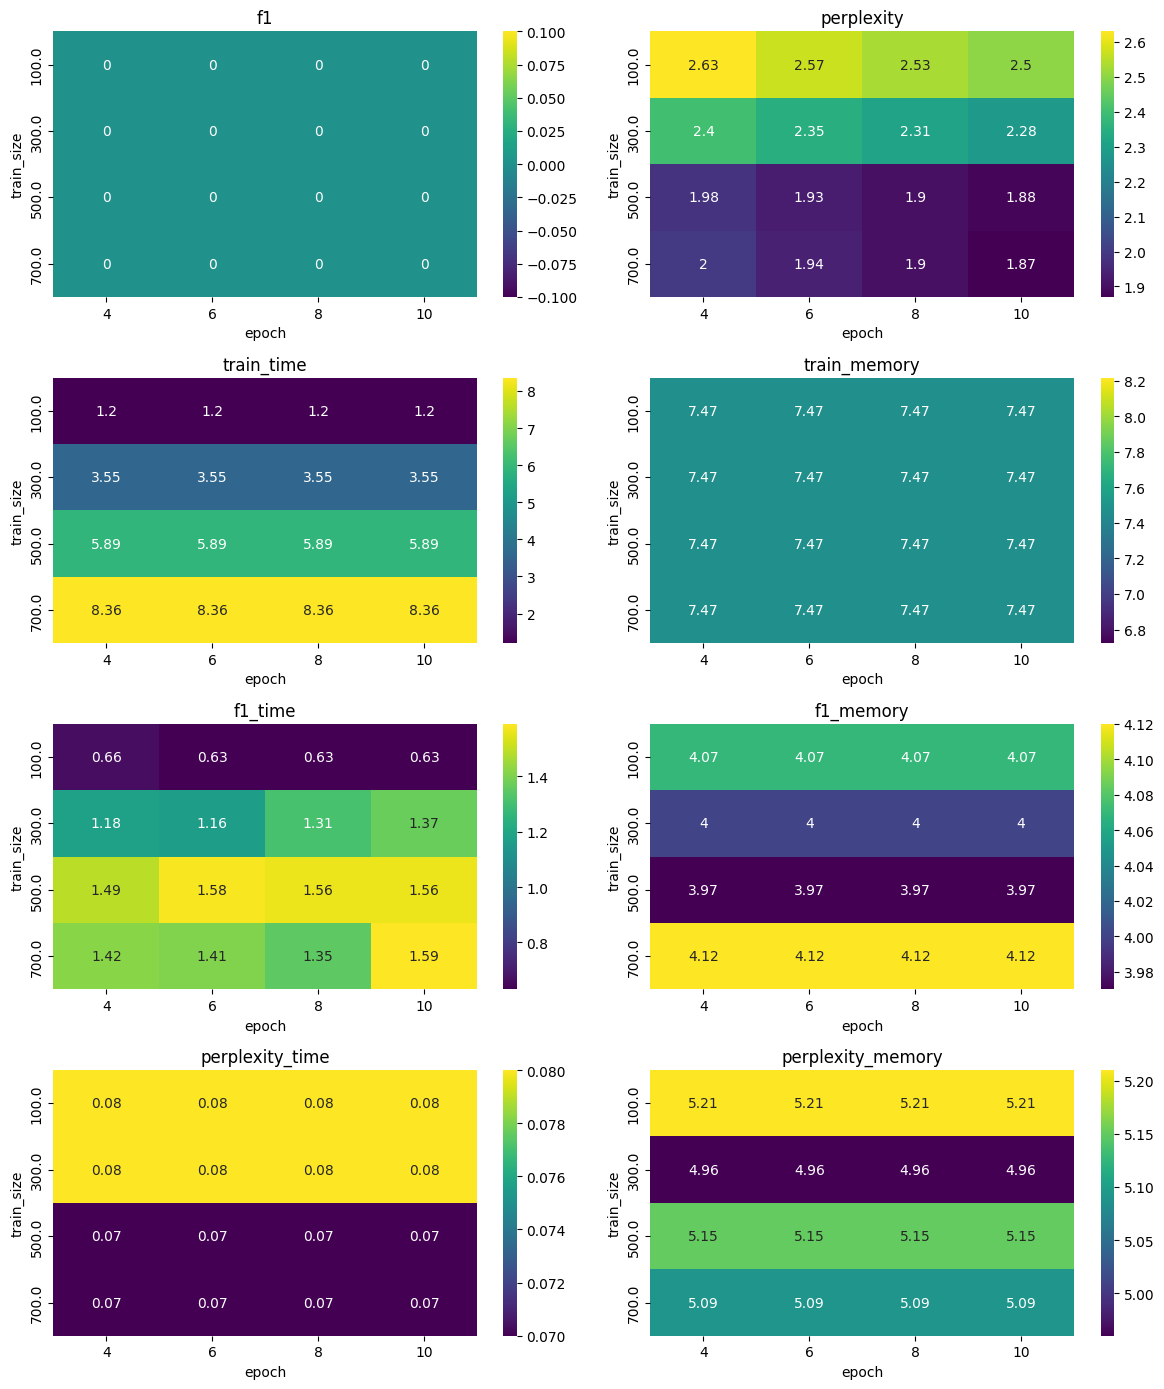

In [36]:

# 3. Все метрики в одном цикле
metrics = ['f1', 'perplexity', 'train_time', 'train_memory',
           'f1_time', 'f1_memory', 'perplexity_time', 'perplexity_memory']

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()
for ax, metric in zip(axes, metrics):
    pivot = df_long.pivot(index='train_size', columns='epoch', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3g', cmap='viridis', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('epoch')
    ax.set_ylabel('train_size')
plt.tight_layout()
plt.show()

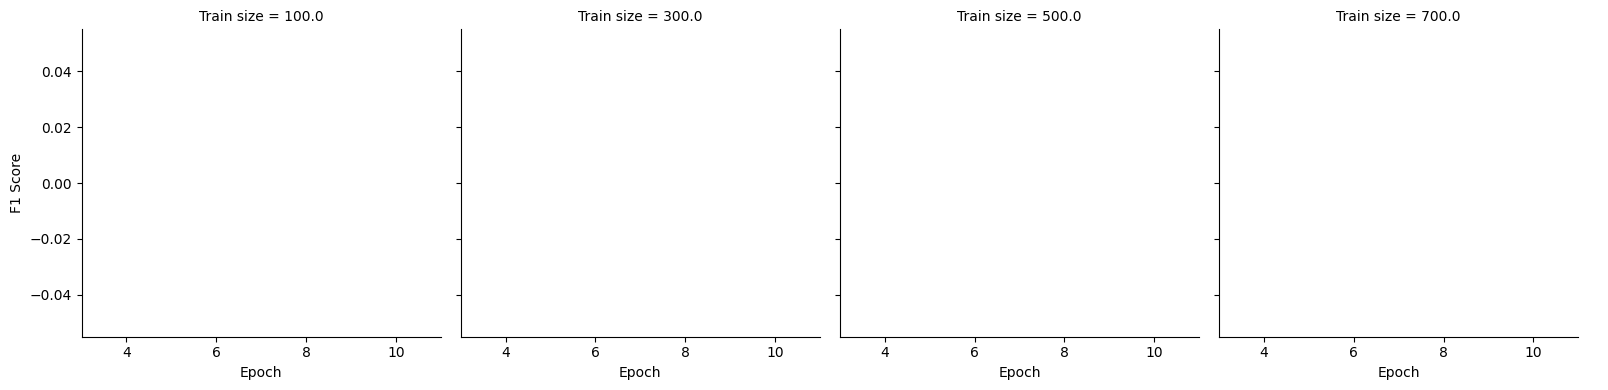

In [37]:
g = sns.catplot(data=df_long, x='epoch', y='f1', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "F1 Score")
g.set_titles("Train size = {col_name}")
plt.show()

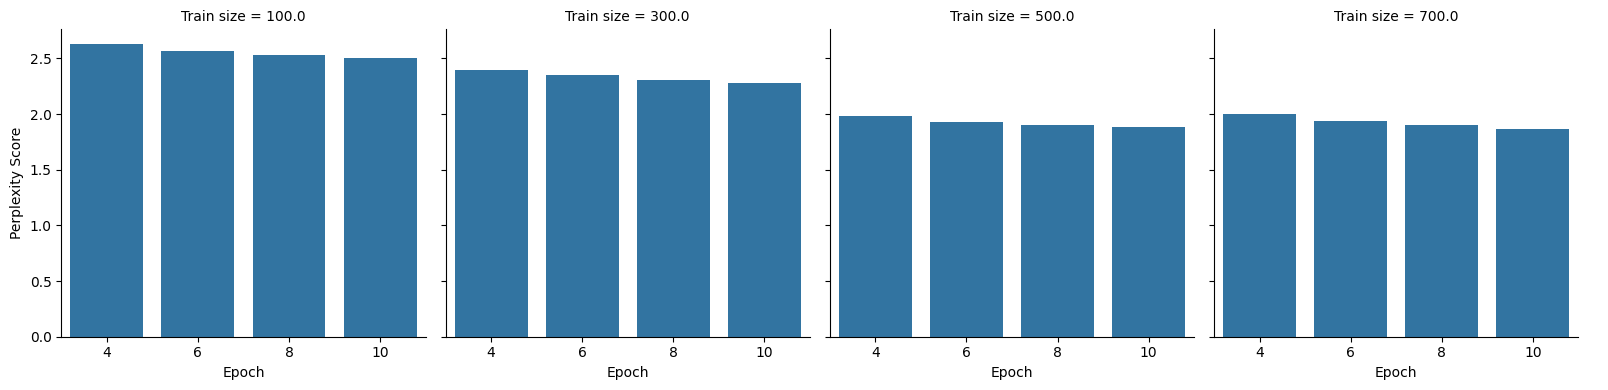

In [38]:
g = sns.catplot(data=df_long, x='epoch', y='perplexity', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "Perplexity Score")
g.set_titles("Train size = {col_name}")
plt.show()

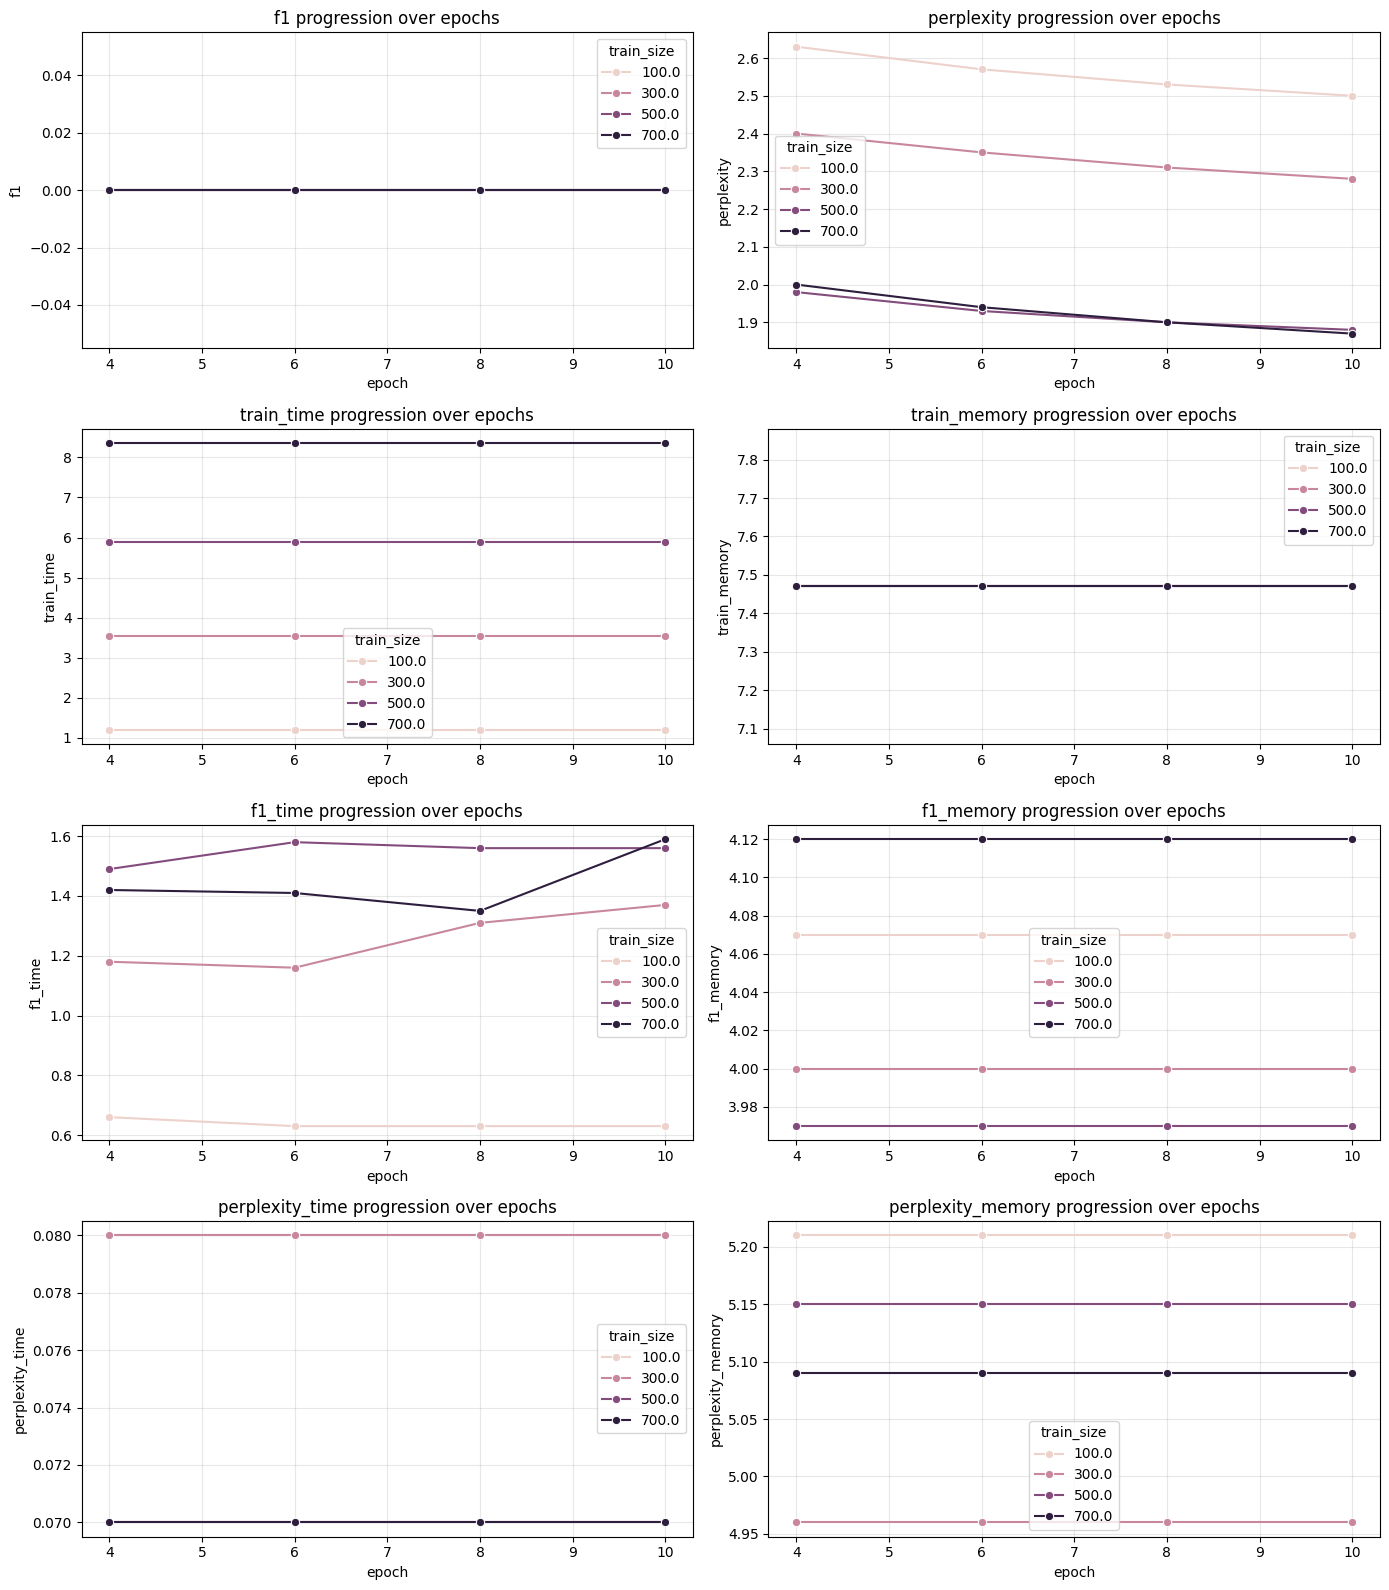

In [39]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.lineplot(data=df_long, x='epoch', y=metric, hue='train_size',
                 marker='o', ax=ax)
    ax.set_title(f'{metric} progression over epochs')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# prompt tuning gold 1.5


In [40]:
df_all = load_all_results("/content/drive/MyDrive/rag_experiments_1_5_second", "results_train_*_prompt_tuning_config_1_5b.csv")
print(df_all)

   train_size  trainable_params_m  before_train_peak_memory_gb  \
0         100                 0.0                         3.76   
1         300                 0.0                         3.76   
2         500                 0.0                         3.76   
3         700                 0.0                         3.76   

   train_time_min  train_peak_memory_gb   f1  evaluate_f1_time_min  \
0            1.00                  7.54  0.0                  1.35   
1            2.96                  7.54  0.0                  1.15   
2            4.91                  7.54  0.0                  0.49   
3            6.98                  7.54  0.0                  0.65   

   evaluate_f1_peak_memory_gb  perplexity  evaluate_perplexity_time_min  ...  \
0                        3.66        2.82                          0.07  ...   
1                        3.62        2.94                          0.07  ...   
2                        3.59        2.53                          0.07  ...  

In [41]:

# 1. Вручную соберём длинный формат
records = []
for _, row in df_all.iterrows():
    train_size = row['train_size']
    for ep in [4, 6, 8, 10]:
        records.append({
            'train_size': train_size,
            'epoch': ep,
            'f1': row[f'f1_epoch{ep}'],
            'perplexity': row[f'perplexity_epoch{ep}'],
            'f1_time': row[f'f1_time_epoch{ep}'],
            'f1_memory': row[f'f1_memory_epoch{ep}'],
            'perplexity_time': row[f'perplexity_time_epoch{ep}'],
            'perplexity_memory': row[f'perplexity_memory_epoch{ep}'],
            'train_time': row['train_time_min'],
            'train_memory': row['train_peak_memory_gb']
        })

df_long = pd.DataFrame(records)


In [42]:
df_long

,train_size,epoch,f1,perplexity,f1_time,f1_memory,perplexity_time,perplexity_memory,train_time,train_memory
0,100.0,4,0.0,2.83,1.25,3.66,0.07,5.25,1.00,7.54
1,100.0,6,0.0,2.83,1.32,3.66,0.07,5.25,1.00,7.54
2,100.0,8,0.0,2.82,1.38,3.66,0.07,5.25,1.00,7.54
3,100.0,10,0.0,2.82,1.35,3.66,0.07,5.25,1.00,7.54
4,300.0,4,0.0,2.96,1.22,3.62,0.07,5.00,2.96,7.54
5,300.0,6,0.0,2.95,1.21,3.61,0.07,5.00,2.96,7.54
6,300.0,8,0.0,2.95,0.67,3.61,0.07,5.00,2.96,7.54
7,300.0,10,0.0,2.94,1.15,3.62,0.07,5.00,2.96,7.54
8,500.0,4,0.0,2.56,0.46,3.60,0.07,5.19,4.91,7.54
9,500.0,6,0.0,2.55,0.45,3.59,0.07,5.19,4.91,7.54


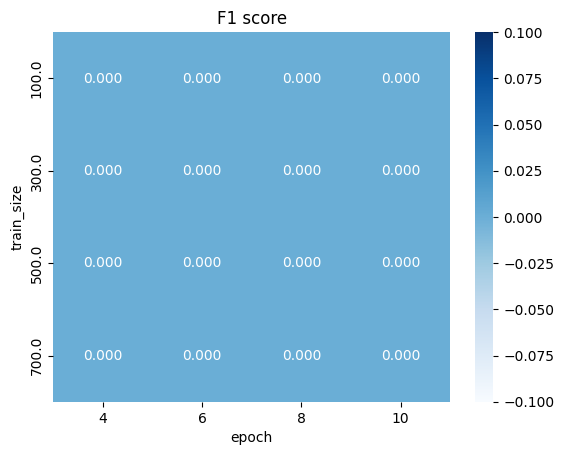

In [43]:

# 2. Heatmap (пример для f1)
pivot_f1 = df_long.pivot(index='train_size', columns='epoch', values='f1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Blues')
plt.title('F1 score')
plt.show()


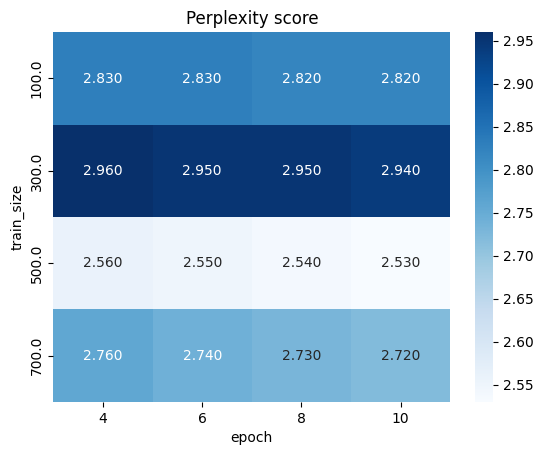

In [44]:

# 2. Heatmap (пример для Perplexity)
pivot_per = df_long.pivot(index='train_size', columns='epoch', values='perplexity')
sns.heatmap(pivot_per, annot=True, fmt='.3f', cmap='Blues')
plt.title('Perplexity score')
plt.show()


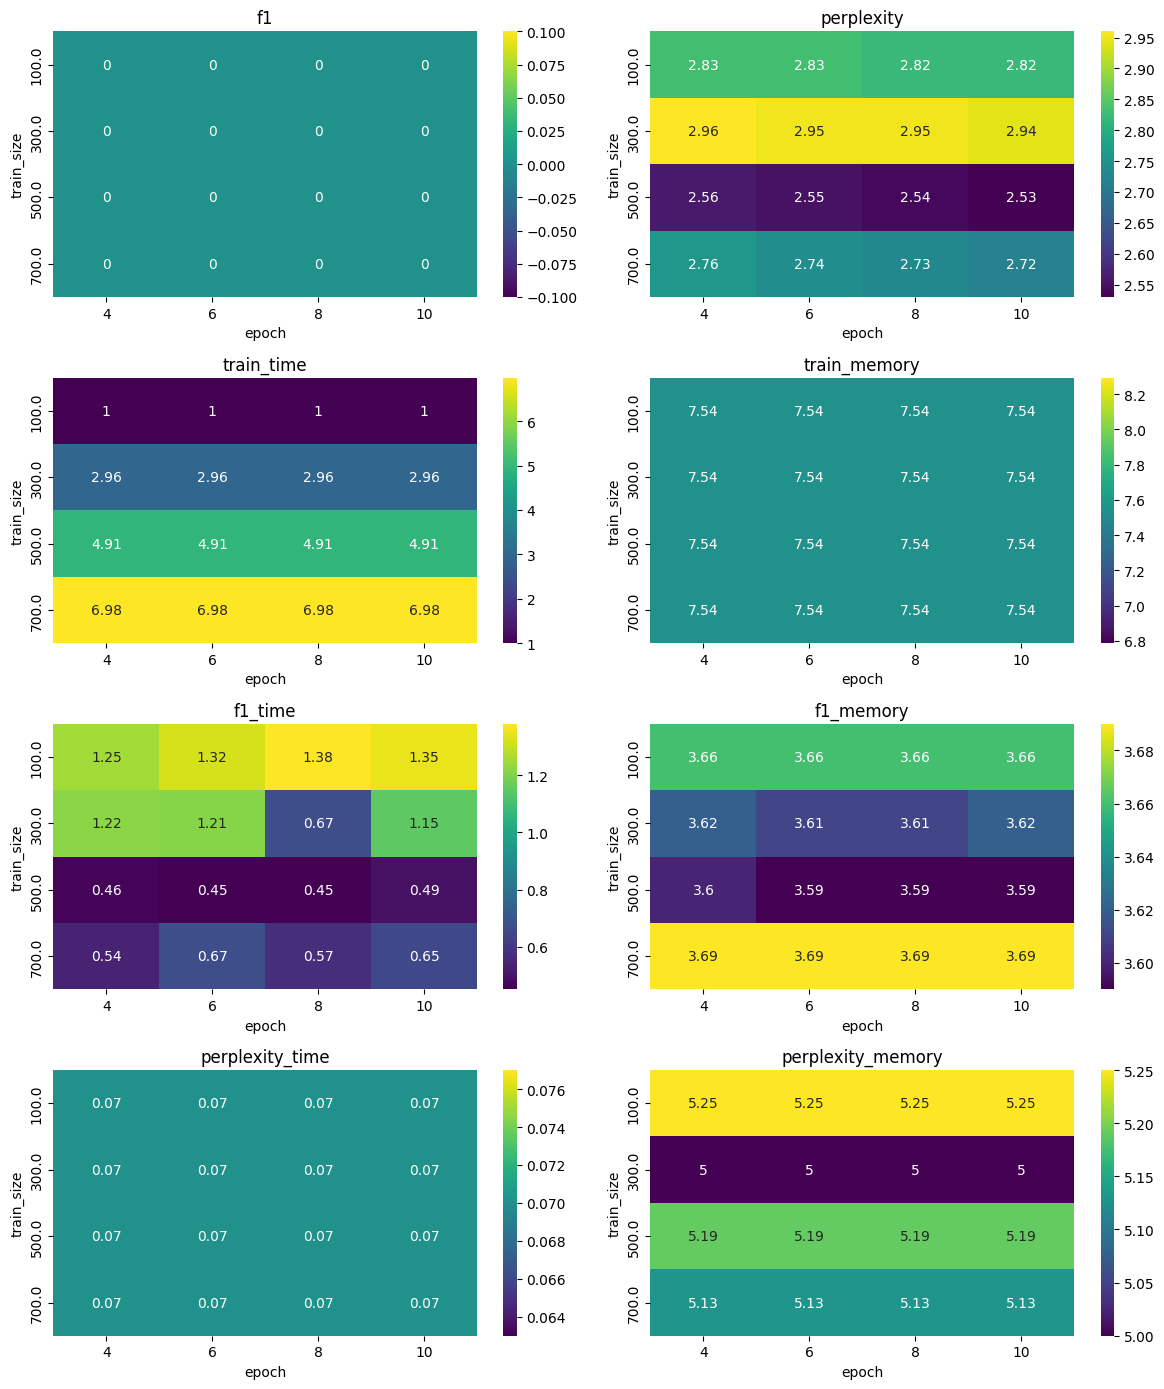

In [45]:

# 3. Все метрики в одном цикле
metrics = ['f1', 'perplexity', 'train_time', 'train_memory',
           'f1_time', 'f1_memory', 'perplexity_time', 'perplexity_memory']

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()
for ax, metric in zip(axes, metrics):
    pivot = df_long.pivot(index='train_size', columns='epoch', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3g', cmap='viridis', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('epoch')
    ax.set_ylabel('train_size')
plt.tight_layout()
plt.show()

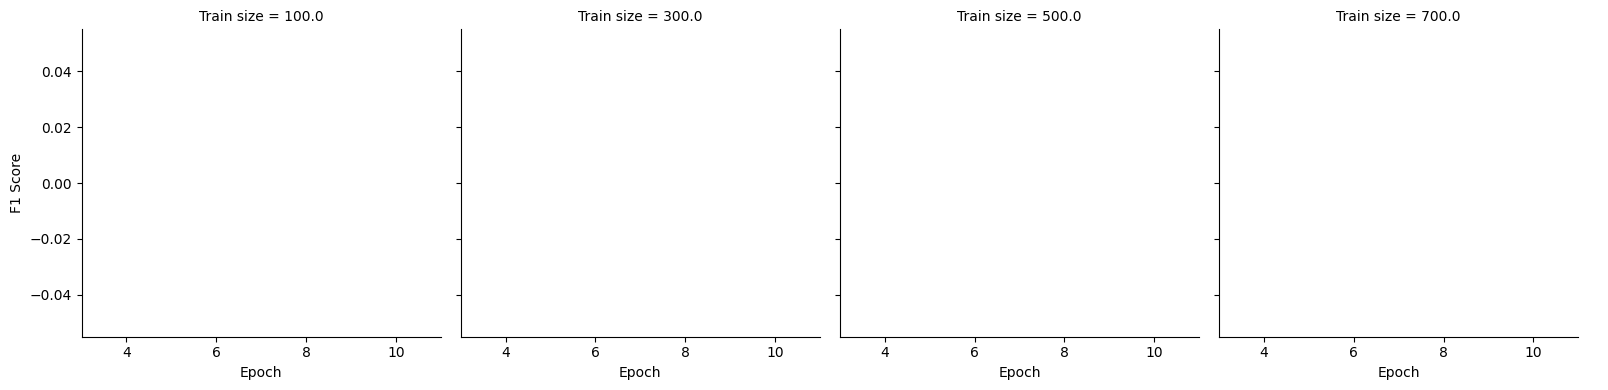

In [46]:
g = sns.catplot(data=df_long, x='epoch', y='f1', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "F1 Score")
g.set_titles("Train size = {col_name}")
plt.show()

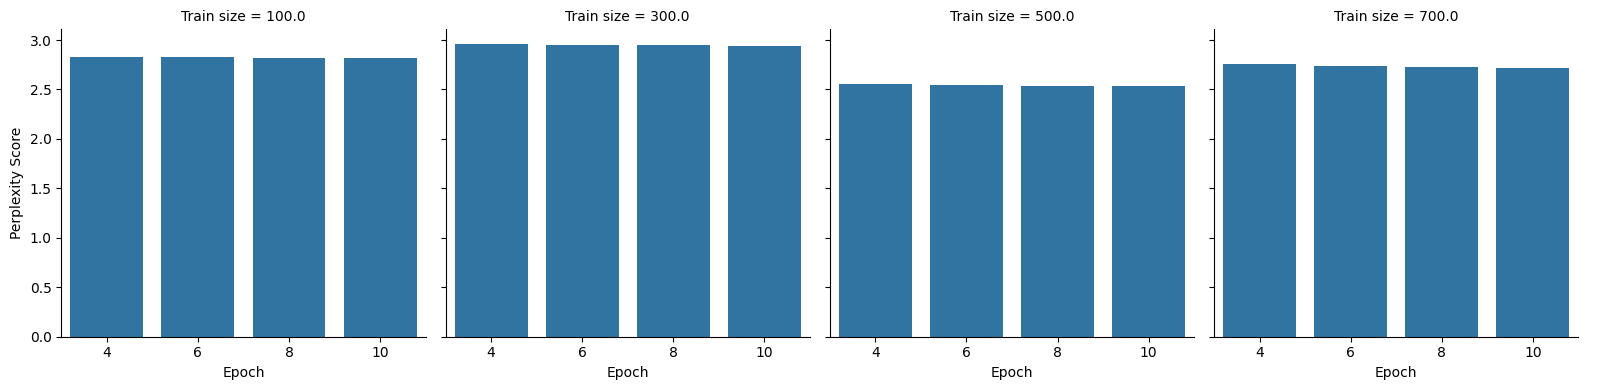

In [47]:
g = sns.catplot(data=df_long, x='epoch', y='perplexity', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "Perplexity Score")
g.set_titles("Train size = {col_name}")
plt.show()

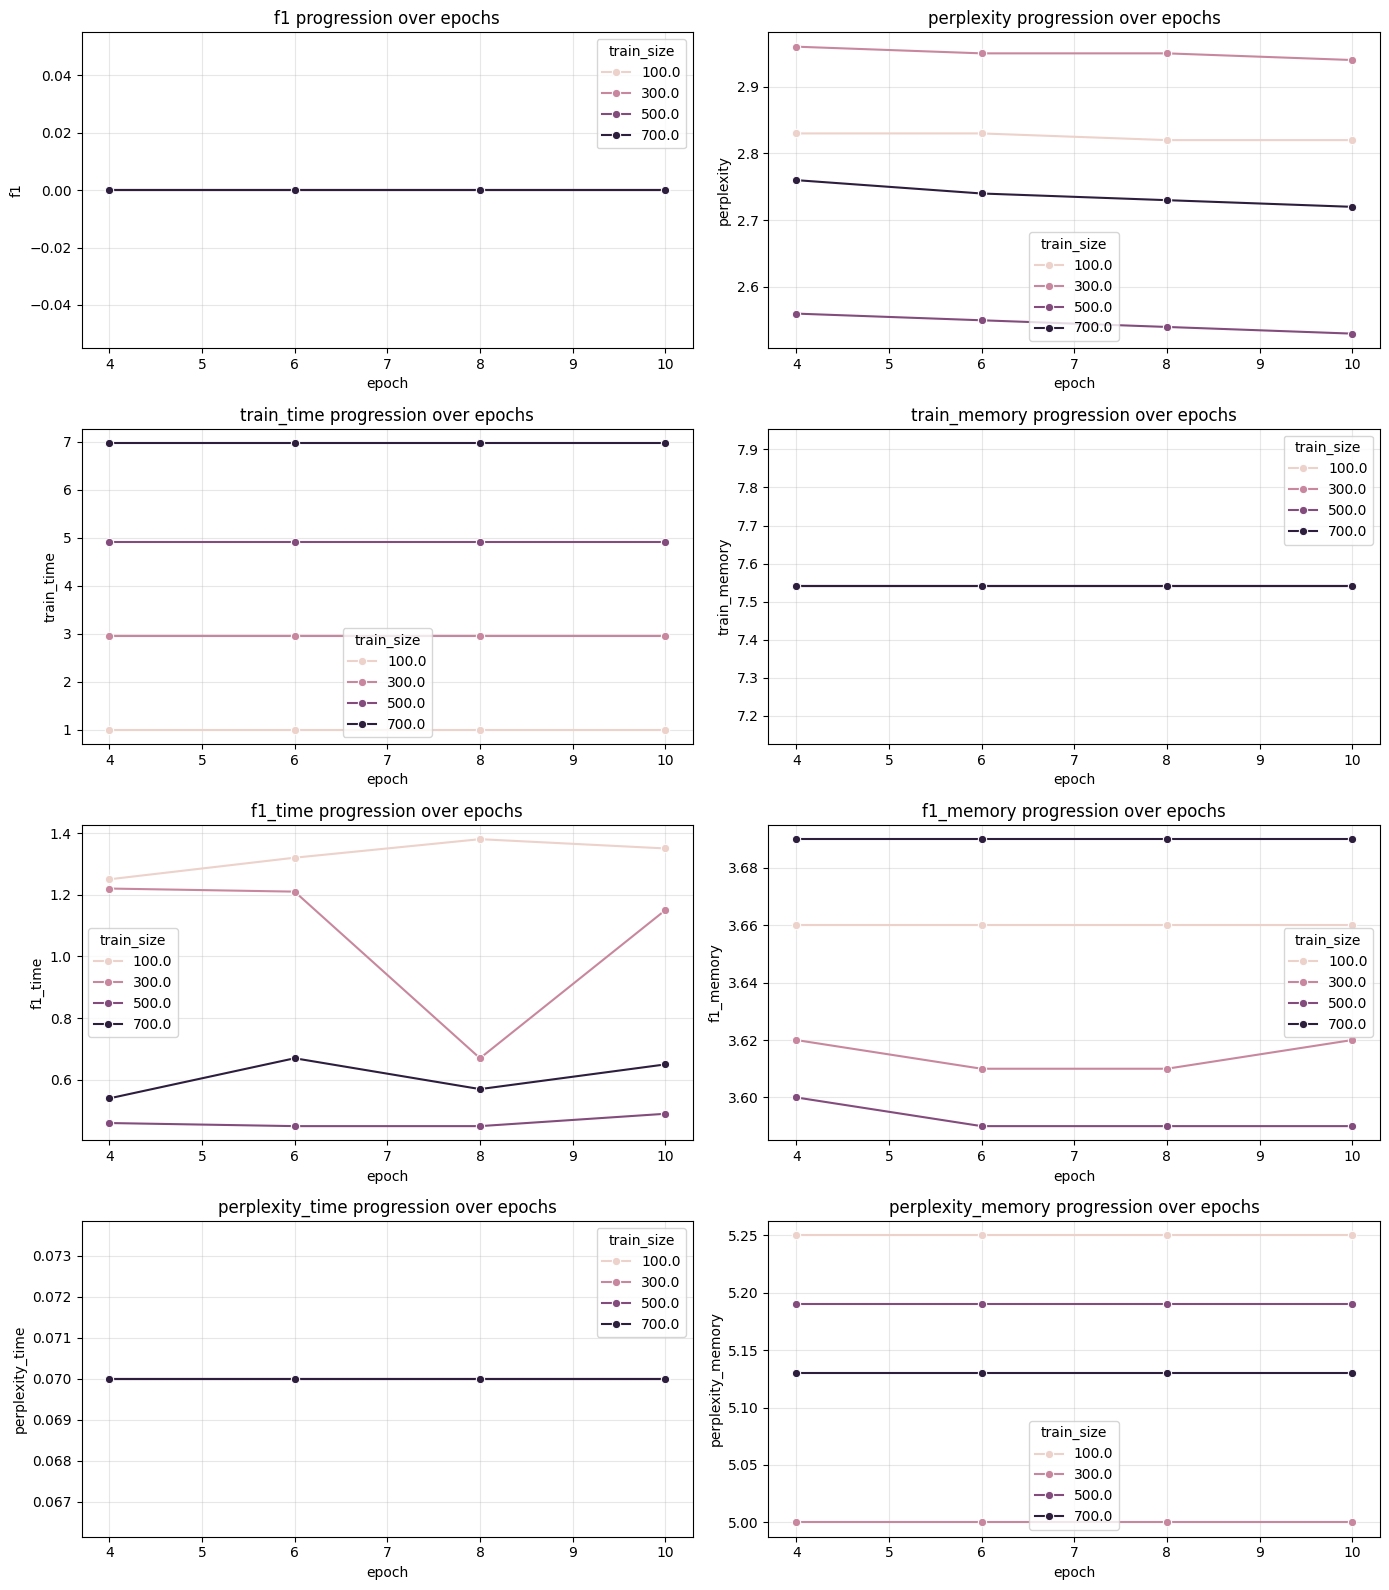

In [48]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.lineplot(data=df_long, x='epoch', y=metric, hue='train_size',
                 marker='o', ax=ax)
    ax.set_title(f'{metric} progression over epochs')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()